## 1. Setup & Installation

In [ ]:
!pip install Sastrawi -q
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import emoji
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/stockbit_reviews.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17360 entries, 0 to 17359
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              17360 non-null  object
 1   userName              17360 non-null  object
 2   userImage             17360 non-null  object
 3   content               17360 non-null  object
 4   score                 17360 non-null  int64 
 5   thumbsUpCount         17360 non-null  int64 
 6   reviewCreatedVersion  14591 non-null  object
 7   at                    17360 non-null  object
 8   replyContent          14511 non-null  object
 9   repliedAt             14511 non-null  object
 10  appVersion            14591 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.5+ MB


## 3. Drop Unnecessary Columns

In [ ]:
# Columns to keep for sentiment analysis
cols_to_drop = ['reviewId', 'userName', 'userImage', 'appVersion']

df = df.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
print(f'Remaining columns: {df.columns.tolist()}')
df.head(3)

Dropped 4 columns: ['reviewId', 'userName', 'userImage', 'appVersion']
Remaining columns: ['content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,mantap,5,0,3.19.5,2026-03-28 10:49:16,NaN,NaN
1,Keren. Sangat membantu. Tapi sayangnya belum a...,5,11,3.19.5,2026-03-28 10:04:59,"Halo kak bujanggila,\n\nTerima kasih atas upda...",2026-03-02 03:49:58
2,udh nunggu lama bgt lebih dari waktu yg di bil...,1,0,3.19.5,2026-03-28 09:19:54,"Halo kak Giffa,\n\nUntuk verifikasi data membu...",2026-03-16 03:08:49


## 4. Handle Missing & Empty Values

In [ ]:
# Check missing values before cleaning
print('Missing values before cleaning:')
df.isnull().sum()

Missing values before cleaning:


,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,2769
at,0
replyContent,2849
repliedAt,2849


In [ ]:
rows_before = len(df)

# Drop rows where 'content' is null or empty/whitespace
df = df.dropna(subset=['content'])
df = df[df['content'].str.strip() != '']

rows_after = len(df)
print(f'Removed {rows_before - rows_after:,} rows with missing/empty content')
print(f'Remaining: {rows_after:,} rows')

Removed 0 rows with missing/empty content
Remaining: 17,360 rows


## 5. Remove Duplicate Reviews

In [ ]:
rows_before = len(df)

df = df.drop_duplicates(subset=['content'], keep='first')

rows_after = len(df)
print(f'Removed {rows_before - rows_after:,} duplicate reviews')
print(f'Remaining: {rows_after:,} unique reviews')

Removed 3,660 duplicate reviews
Remaining: 13,700 unique reviews


## 6. Convert Data Types

In [ ]:
df['at'] = pd.to_datetime(df['at'])
df['repliedAt'] = pd.to_datetime(df['repliedAt'])

df.dtypes

,0
content,object
score,int64
thumbsUpCount,int64
reviewCreatedVersion,object
at,datetime64[ns]
replyContent,object
repliedAt,datetime64[ns]


## 7. Sentiment Labeling

We create a sentiment label based on the review score. This labeled column will serve as the target variable for sentiment classification.

| Score | Sentiment |
|-------|-----------|
| 1 - 2 | Negative |
| 3     | Neutral  |
| 4 - 5 | Positive |

In [ ]:
def assign_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['score'].apply(assign_sentiment)

df['sentiment'].value_counts()

,count
sentiment,
positive,8513
negative,4263
neutral,924


## 8. Text Preprocessing

### 8.1 Case Folding (Lowercasing)

In [ ]:
df['cleaned_content'] = df['content'].astype(str).str.lower()

# Show before vs after
df[['content', 'cleaned_content']].head(5)

,content,cleaned_content
0,mantap,mantap
1,Keren. Sangat membantu. Tapi sayangnya belum a...,keren. sangat membantu. tapi sayangnya belum a...
2,udh nunggu lama bgt lebih dari waktu yg di bil...,udh nunggu lama bgt lebih dari waktu yg di bil...
3,penipuan,penipuan
4,aplikasi investasi yang sngat dipercaya,aplikasi investasi yang sngat dipercaya


### 8.2 Text Cleaning

In [ ]:
def clean_text(text):
    """Remove non-textual noise from a review string."""
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove emojis
    text = emoji.replace_emoji(text, replace='')
    # Remove digits/numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaned_content'] = df['cleaned_content'].apply(clean_text)

#before vs after
df[['content', 'cleaned_content']].sample(5, random_state=42)

,content,cleaned_content
12498,Aplikasi yang sangat merugikan buat para trade...,aplikasi yang sangat merugikan buat para trade...
13127,Kasih fitur top broker min,kasih fitur top broker min
1395,josss,josss
10640,Parah stockbit dari pagi maintenance ngga sele...,parah stockbit dari pagi maintenance ngga sele...
9639,Ini sangat parah menurut saya. Waktunya IPO ma...,ini sangat parah menurut saya waktunya ipo mal...


### 8.3 Indonesian Slang Normalization

In [ ]:
slang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'gk': 'tidak', 'g': 'tidak', 'tdk': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak', 'kagak': 'tidak',
    'tp': 'tapi', 'tpi': 'tapi',
    'utk': 'untuk', 'tuk': 'untuk', 'buat': 'untuk', 'u': 'untuk',
    'yg': 'yang', 'yng': 'yang',
    'dg': 'dengan', 'dgn': 'dengan', 'sm': 'dengan',
    'udh': 'sudah', 'sdh': 'sudah', 'udah': 'sudah', 'uda': 'sudah',
    'blm': 'belum', 'blom': 'belum',
    'lg': 'lagi', 'lgi': 'lagi',
    'bs': 'bisa', 'bsa': 'bisa',
    'klo': 'kalau', 'kl': 'kalau', 'klu': 'kalau', 'kalo': 'kalau',
    'jg': 'juga', 'jga': 'juga',
    'aja': 'saja', 'aj': 'saja',
    'dr': 'dari',
    'krn': 'karena', 'karna': 'karena', 'krna': 'karena',
    'bgt': 'banget', 'bngt': 'banget', 'bngtt': 'banget',
    'bgtt': 'banget', 'bangett': 'banget', 'bener': 'benar',
    'emg': 'memang', 'emang': 'memang',
    'hrs': 'harus',
    'jd': 'jadi', 'jdi': 'jadi',
    'dpt': 'dapat',
    'skrg': 'sekarang', 'skrng': 'sekarang', 'skg': 'sekarang',
    'trs': 'terus', 'trus': 'terus',
    'org': 'orang', 'ornag': 'orang',
    'msh': 'masih',
    'sy': 'saya', 'aku': 'saya', 'gw': 'saya', 'gue': 'saya', 'gua': 'saya', 'w': 'saya',
    'lo': 'kamu', 'lu': 'kamu',
    'gmn': 'bagaimana', 'gimana': 'bagaimana',
    'knp': 'kenapa', 'knapa': 'kenapa',
    'bnr': 'benar',
    'bkn': 'bukan',
    'dmn': 'dimana', 'dmna': 'dimana',
    'gpp': 'tidak apa apa', 'gapapa': 'tidak apa apa',
    'makasih': 'terima kasih', 'makasi': 'terima kasih', 'thx': 'terima kasih', 'thanks': 'terima kasih', 'tq': 'terima kasih',
    'mantap': 'bagus', 'mantab': 'bagus', 'mantapp': 'bagus',
    'top': 'bagus', 'josss': 'bagus', 'jos': 'bagus', 'keren': 'bagus',
    'jelek': 'buruk', 'parah': 'buruk', 'ancur': 'buruk', 'sampah': 'buruk',
    'apk': 'aplikasi', 'app': 'aplikasi',
    'hp': 'handphone',
    'banget': 'sekali',
    'bner': 'benar',
    'ngk': 'tidak', 'engga': 'tidak', 'enggak': 'tidak',
    'dlu': 'dulu', 'dl': 'dulu',
    'pke': 'pakai', 'pake': 'pakai', 'pk': 'pakai',
    'smpe': 'sampai', 'smpai': 'sampai', 'sampe': 'sampai',
    'ntar': 'nanti', 'tar': 'nanti',
    'kmrn': 'kemarin', 'kmarin': 'kemarin',
}

print(f'Slang dictionary size: {len(slang_dict)} entries')

Slang dictionary size: 115 entries


In [ ]:
def normalize_slang(text):
    """Replace Indonesian slang words with their standard form."""
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized)


df['cleaned_content'] = df['cleaned_content'].apply(normalize_slang)

# Show examples where slang was normalized
changed_mask = df['content'].astype(str).str.lower() != df['cleaned_content']
df[changed_mask][['content', 'cleaned_content']].head(5)

,content,cleaned_content
0,mantap,bagus
1,Keren. Sangat membantu. Tapi sayangnya belum a...,bagus sangat membantu tapi sayangnya belum ada...
2,udh nunggu lama bgt lebih dari waktu yg di bil...,sudah nunggu lama banget lebih dari waktu yang...
5,aplikasi sangat bagus gak banyak jebakan.. CS ...,aplikasi sangat bagus tidak banyak jebakan cs ...
6,Aplikasi ini bagus...saking bagus....banyak bu...,aplikasi ini bagussaking bagusbanyak bug nya


### 8.4 Tokenization

In [ ]:
df['tokens'] = df['cleaned_content'].apply(word_tokenize)

df[['cleaned_content', 'tokens']].head(5)

,cleaned_content,tokens
0,bagus,[bagus]
1,bagus sangat membantu tapi sayangnya belum ada...,"[bagus, sangat, membantu, tapi, sayangnya, bel..."
2,sudah nunggu lama banget lebih dari waktu yang...,"[sudah, nunggu, lama, banget, lebih, dari, wak..."
3,penipuan,[penipuan]
4,aplikasi investasi yang sngat dipercaya,"[aplikasi, investasi, yang, sngat, dipercaya]"


### 8.5 Stopword Removal (Indonesian)

In [ ]:
# Load Sastrawi's Indonesian stopwords
stop_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stop_factory.get_stop_words())

# Add custom domain-specific stopwords
custom_stopwords = {
    'stockbit', 'sb', 'aplikasi', 'handphone',
    'nya', 'aja', 'sih', 'dong', 'deh', 'loh', 'nih', 'lah', 'kan', 'kok',
    'ya', 'yah', 'oh', 'ah', 'eh', 'wah',
    'tuh', 'tau', 'mau', 'mulu', 'nih', 'gitu', 'gini',
}

all_stopwords = indonesian_stopwords.union(custom_stopwords)

print(f'Sastrawi stopwords  : {len(indonesian_stopwords)}')
print(f'Custom stopwords    : {len(custom_stopwords)}')
print(f'Total stopwords     : {len(all_stopwords)}')
print(f'\nSample stopwords: {sorted(list(all_stopwords))[:20]}')

Sastrawi stopwords  : 123
Custom stopwords    : 26
Total stopwords     : 147

Sample stopwords: ['ada', 'adalah', 'agak', 'agar', 'ah', 'aja', 'akan', 'amat', 'anda', 'antara', 'anu', 'apakah', 'apalagi', 'aplikasi', 'atau', 'bagaimanapun', 'bagi', 'bahwa', 'begitu', 'belum']


In [ ]:
def remove_stopwords(tokens):
    """Remove Indonesian stopwords from token list."""
    return [t for t in tokens if t not in all_stopwords and len(t) > 1]


df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

df[['tokens', 'tokens_no_sw']].head(5)

,tokens,tokens_no_sw
0,[bagus],[bagus]
1,"[bagus, sangat, membantu, tapi, sayangnya, bel...","[bagus, sangat, membantu, sayangnya, trailing,..."
2,"[sudah, nunggu, lama, banget, lebih, dari, wak...","[nunggu, lama, banget, lebih, waktu, bilanghar..."
3,[penipuan],[penipuan]
4,"[aplikasi, investasi, yang, sngat, dipercaya]","[investasi, sngat, dipercaya]"


### 8.6 Stemming (Sastrawi — Indonesian)

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 1. Inisialisasi stemmer HANYA SEKALI
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# 2. Ambil semua kata unik dari seluruh dataset
# Ini trik rahasia biar cepat: jangan stem kalimat, tapi stem kamus kata uniknya
all_words = [word for sublist in df['tokens_no_sw'] for word in sublist]
unique_words = list(set(all_words))

print(f"Total kata di dataset: {len(all_words)}")
print(f"Total kata unik: {len(unique_words)}")

# 3. Stemming hanya pada kata yang unik (disimpan dalam dictionary)
stem_map = {}
for i, word in enumerate(unique_words):
    stem_map[word] = stemmer.stem(word)
    if (i+1) % 500 == 0: # Progress bar sederhana
        print(f"Progress: {i+1}/{len(unique_words)} kata unik selesai...")

# 4. Terapkan (Map) kembali ke kolom dataframe
df['tokens_stemmed'] = df['tokens_no_sw'].apply(lambda x: [stem_map[word] for word in x])

print("Stemming selesai!")

Total kata di dataset: 105466
Total kata unik: 12136
Progress: 500/12136 kata unik selesai...
Progress: 1000/12136 kata unik selesai...
Progress: 1500/12136 kata unik selesai...
Progress: 2000/12136 kata unik selesai...
Progress: 2500/12136 kata unik selesai...
Progress: 3000/12136 kata unik selesai...
Progress: 3500/12136 kata unik selesai...
Progress: 4000/12136 kata unik selesai...
Progress: 4500/12136 kata unik selesai...
Progress: 5000/12136 kata unik selesai...
Progress: 5500/12136 kata unik selesai...
Progress: 6000/12136 kata unik selesai...
Progress: 6500/12136 kata unik selesai...
Progress: 7000/12136 kata unik selesai...
Progress: 7500/12136 kata unik selesai...
Progress: 8000/12136 kata unik selesai...
Progress: 8500/12136 kata unik selesai...
Progress: 9000/12136 kata unik selesai...
Progress: 9500/12136 kata unik selesai...
Progress: 10000/12136 kata unik selesai...
Progress: 10500/12136 kata unik selesai...
Progress: 11000/12136 kata unik selesai...
Progress: 11500/12136

### 8.7 Reconstruct Cleaned Text

In [ ]:
df['final_text'] = df['tokens_stemmed'].apply(lambda tokens: ' '.join(tokens))

df[['content', 'final_text']].head(10)

,content,final_text
0,mantap,bagus
1,Keren. Sangat membantu. Tapi sayangnya belum a...,bagus sangat bantu sayang trailing stop ayo ja...
2,udh nunggu lama bgt lebih dari waktu yg di bil...,nunggu lama banget lebih waktu bilanghari muda...
3,penipuan,tipu
4,aplikasi investasi yang sngat dipercaya,investasi sngat percaya
5,aplikasi sangat bagus gak banyak jebakan.. CS ...,sangat bagus banyak jebak cs respon
6,Aplikasi ini bagus...saking bagus....banyak bu...,bagussaking bagusbanyak bug
7,bagus sekali,bagus sekali
8,stockbit memberikan pengalaman terbaik bagi pe...,beri alam baik guna saham newbie amanah
9,"Aplikasinya Oke, belum nemu kendala 👌",aplikasi oke nemu kendala


In [ ]:
# Remove rows where final_text is empty after all preprocessing
rows_before = len(df)
df = df[df['final_text'].str.strip() != '']
rows_after = len(df)

print(f'Removed {rows_before - rows_after:,} rows with empty text after preprocessing')
print(f'Final dataset size: {rows_after:,} reviews')

Removed 108 rows with empty text after preprocessing
Final dataset size: 13,592 reviews


## 9. Post-Preprocessing Validation

In [ ]:
# Original vs Final
comparison = df[['content', 'final_text', 'score', 'sentiment']].sample(10, random_state=42)
comparison

,content,final_text,score,sentiment
1176,sangat baik dan efesien bagi pemula yang mulai...,sangat baik efesien mula mulai mengenalinvestasi,5,positive
4468,Aplikasi sangat bagus dan mudah digunakan,sangat bagus mudah guna,5,positive
4040,"Invest kriptonya segera dirilis, biar ga ribet...",invest kriptonya segera rilis biar ribet pinda...,3,neutral
8862,"Sedikit2 beralih kesekuritas lain,, mulai bula...",sedikit alih sekuritas mulai bulan depan mulai...,1,negative
8031,app paling rekomended.. 👌,paling rekomended,5,positive
9124,Excellent....,excellent,5,positive
7225,Bagus apliksinya,bagus apliksinya,5,positive
13338,Bagus masih tahap belajar,bagus tahap ajar,5,positive
6524,Bagus dan sangat menarik,bagus sangat tarik,5,positive
6481,daftar aj nunggu verifikasi dr bank RDN lama b...,daftar nunggu verifikasi bank rdn lama bnget j...,2,negative


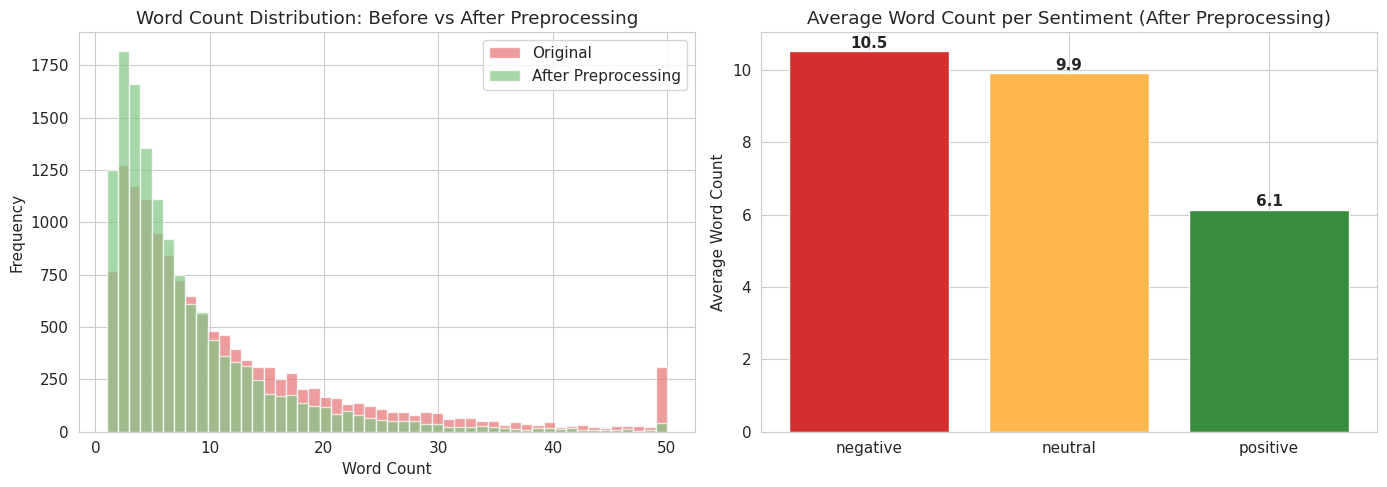

In [ ]:
# 9.2 — Word count comparison: before vs after
df['original_word_count'] = df['content'].astype(str).str.split().str.len()
df['final_word_count'] = df['final_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['original_word_count'].clip(upper=50), bins=50, alpha=0.7,
             color='#e57373', label='Original')
axes[0].hist(df['final_word_count'].clip(upper=50), bins=50, alpha=0.7,
             color='#81c784', label='After Preprocessing')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution: Before vs After Preprocessing')
axes[0].legend()

# Average word count by sentiment
sent_order = ['negative', 'neutral', 'positive']
avg_wc = df.groupby('sentiment')['final_word_count'].mean().reindex(sent_order)
bar_colors = [colors_sent[s] for s in sent_order]
axes[1].bar(sent_order, avg_wc.values, color=bar_colors, edgecolor='white')
axes[1].set_ylabel('Average Word Count')
axes[1].set_title('Average Word Count per Sentiment (After Preprocessing)')
for i, v in enumerate(avg_wc.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

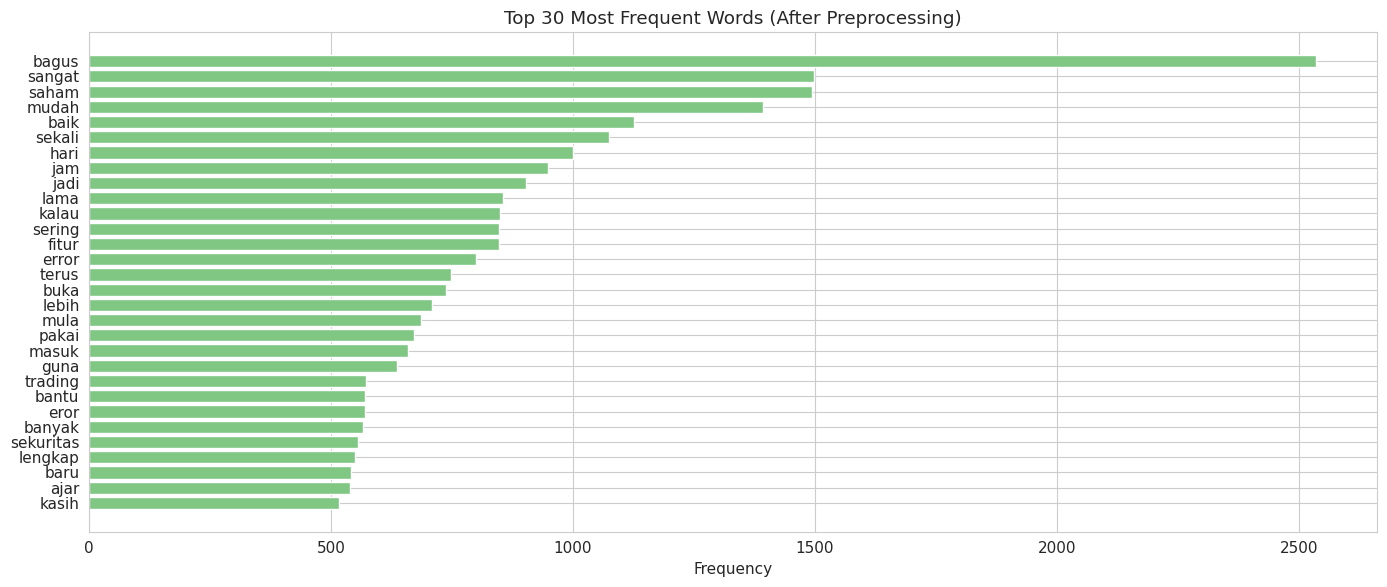

In [ ]:
# 9.3 — Top words AFTER preprocessing (compare with EDA's raw word frequency)
all_final_words = ' '.join(df['final_text']).split()
final_word_freq = Counter(all_final_words)

top_30_final = final_word_freq.most_common(30)
words_f, counts_f = zip(*top_30_final)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(range(len(words_f)), counts_f, color='#81c784', edgecolor='white')
ax.set_yticks(range(len(words_f)))
ax.set_yticklabels(words_f)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Words (After Preprocessing)')
plt.tight_layout()
plt.show()

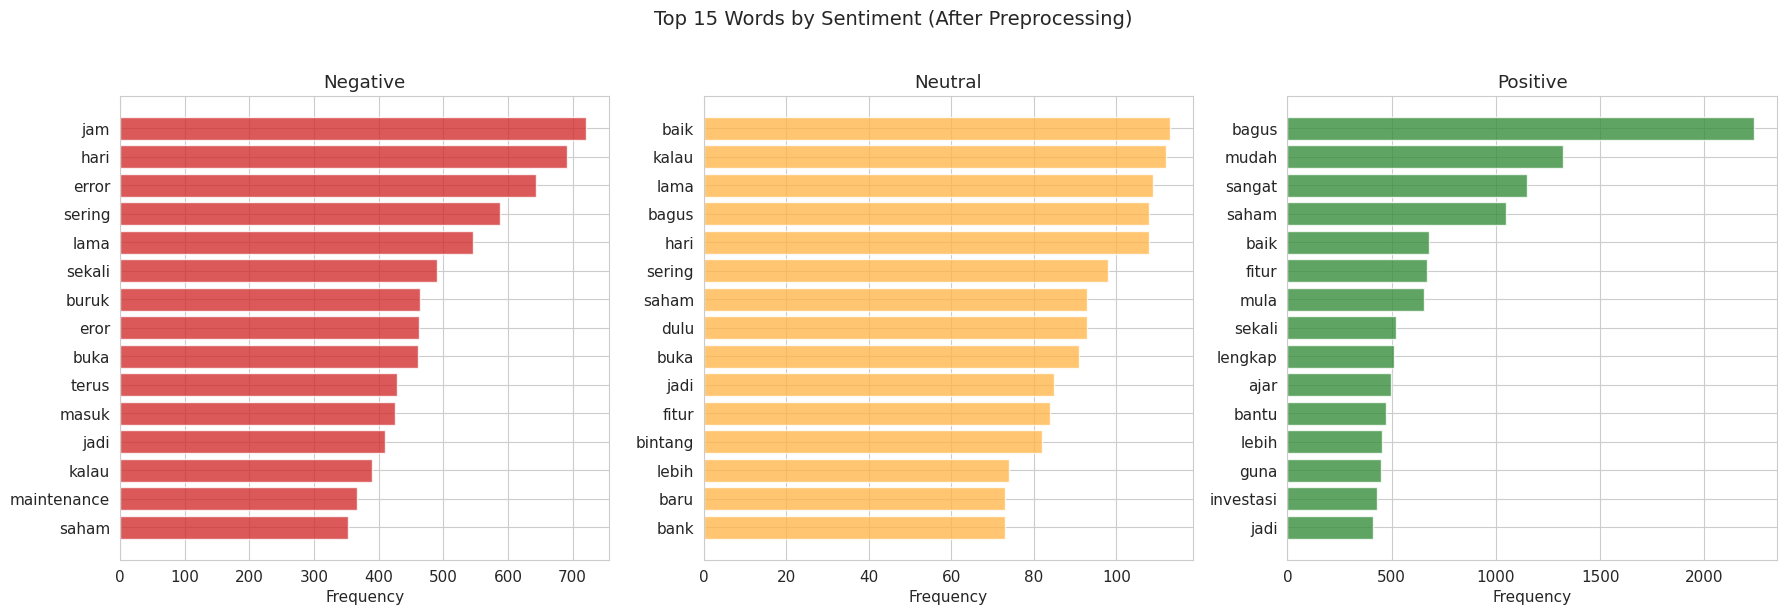

In [ ]:
# 9.4 — Top words by sentiment group (after preprocessing)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sent_groups = {
    'Negative': df[df['sentiment'] == 'negative'],
    'Neutral': df[df['sentiment'] == 'neutral'],
    'Positive': df[df['sentiment'] == 'positive']
}
group_colors = ['#d32f2f', '#ffb74d', '#388e3c']

for ax, (label, grp_df), color in zip(axes, sent_groups.items(), group_colors):
    grp_words = Counter(' '.join(grp_df['final_text']).split()).most_common(15)
    w, c = zip(*grp_words)
    ax.barh(range(len(w)), c, color=color, alpha=0.8)
    ax.set_yticks(range(len(w)))
    ax.set_yticklabels(w)
    ax.invert_yaxis()
    ax.set_title(f'{label}')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words by Sentiment (After Preprocessing)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Final Data Overview & Column Selection

In [ ]:
# 10.1 — Final dataframe overview
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13592 entries, 0 to 17359
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   content               13592 non-null  object        
 1   score                 13592 non-null  int64         
 2   thumbsUpCount         13592 non-null  int64         
 3   reviewCreatedVersion  11338 non-null  object        
 4   at                    13592 non-null  datetime64[ns]
 5   replyContent          11679 non-null  object        
 6   repliedAt             11679 non-null  datetime64[ns]
 7   sentiment             13592 non-null  object        
 8   cleaned_content       13592 non-null  object        
 9   tokens                13592 non-null  object        
 10  token_count           13592 non-null  int64         
 11  tokens_no_sw          13592 non-null  object        
 12  tokens_stemmed        13592 non-null  object        
 13  final_text           

In [ ]:
df.head(5)

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sentiment,cleaned_content,tokens,token_count,tokens_no_sw,tokens_stemmed,final_text,original_word_count,final_word_count
0,mantap,5,0,3.19.5,2026-03-28 10:49:16,NaN,NaT,positive,bagus,[bagus],1,[bagus],[bagus],bagus,1,1
1,Keren. Sangat membantu. Tapi sayangnya belum a...,5,11,3.19.5,2026-03-28 10:04:59,"Halo kak bujanggila,\n\nTerima kasih atas upda...",2026-03-02 03:49:58,positive,bagus sangat membantu tapi sayangnya belum ada...,"[bagus, sangat, membantu, tapi, sayangnya, bel...",46,"[bagus, sangat, membantu, sayangnya, trailing,...","[bagus, sangat, bantu, sayang, trailing, stop,...",bagus sangat bantu sayang trailing stop ayo ja...,46,28
2,udh nunggu lama bgt lebih dari waktu yg di bil...,1,0,3.19.5,2026-03-28 09:19:54,"Halo kak Giffa,\n\nUntuk verifikasi data membu...",2026-03-16 03:08:49,negative,sudah nunggu lama banget lebih dari waktu yang...,"[sudah, nunggu, lama, banget, lebih, dari, wak...",24,"[nunggu, lama, banget, lebih, waktu, bilanghar...","[nunggu, lama, banget, lebih, waktu, bilanghar...",nunggu lama banget lebih waktu bilanghari muda...,24,14
3,penipuan,1,0,NaN,2026-03-28 08:59:03,NaN,NaT,negative,penipuan,[penipuan],1,[penipuan],[tipu],tipu,1,1
4,aplikasi investasi yang sngat dipercaya,5,0,3.19.5,2026-03-28 04:08:53,NaN,NaT,positive,aplikasi investasi yang sngat dipercaya,"[aplikasi, investasi, yang, sngat, dipercaya]",5,"[investasi, sngat, dipercaya]","[investasi, sngat, percaya]",investasi sngat percaya,5,3


In [ ]:
# 10.2 — Select and save only the columns needed for sentiment analysis
cols_to_save = ['content', 'score', 'at', 'thumbsUpCount', 'replyContent',
                'sentiment', 'final_text', 'tokens_stemmed']

df_clean = df[cols_to_save].copy()

print(f'Columns selected for export: {cols_to_save}')
print(f'Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
df_clean.head(5)

Columns selected for export: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'sentiment', 'final_text', 'tokens_stemmed']
Final shape: 13,592 rows × 8 columns


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_stemmed
0,mantap,5,2026-03-28 10:49:16,0,NaN,positive,bagus,[bagus]
1,Keren. Sangat membantu. Tapi sayangnya belum a...,5,2026-03-28 10:04:59,11,"Halo kak bujanggila,\n\nTerima kasih atas upda...",positive,bagus sangat bantu sayang trailing stop ayo ja...,"[bagus, sangat, bantu, sayang, trailing, stop,..."
2,udh nunggu lama bgt lebih dari waktu yg di bil...,1,2026-03-28 09:19:54,0,"Halo kak Giffa,\n\nUntuk verifikasi data membu...",negative,nunggu lama banget lebih waktu bilanghari muda...,"[nunggu, lama, banget, lebih, waktu, bilanghar..."
3,penipuan,1,2026-03-28 08:59:03,0,NaN,negative,tipu,[tipu]
4,aplikasi investasi yang sngat dipercaya,5,2026-03-28 04:08:53,0,NaN,positive,investasi sngat percaya,"[investasi, sngat, percaya]"


## 11. Save Preprocessed Data

In [ ]:
# Save to CSV
output_path = '../content/stockbit_reviews_clean.csv'
df_clean.to_csv(output_path, index=False)

print(f'Preprocessed data saved to: {output_path}')
print(f'Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

Preprocessed data saved to: ../content/stockbit_reviews_clean.csv
Shape: 13,592 rows × 8 columns
